In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



In [10]:
data = pd.read_csv("/content/Medical Cost Personal Datasets.csv")
df = pd.DataFrame(data)
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [11]:
X = df[['age','bmi','children', 'smoker', 'region']]

In [12]:
Y = df['charges']

In [13]:
df['smoker'] = df['smoker'].map({'yes':1,'no':0})


In [14]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,1,southwest,16884.92400
1,18,male,33.770,1,0,southeast,1725.55230
2,28,male,33.000,3,0,southeast,4449.46200
3,33,male,22.705,0,0,northwest,21984.47061
4,32,male,28.880,0,0,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,0,northwest,10600.54830
1334,18,female,31.920,0,0,northeast,2205.98080
1335,18,female,36.850,0,0,southeast,1629.83350
1336,21,female,25.800,0,0,southwest,2007.94500


In [15]:
df = pd.get_dummies(df, columns=['region'],dtype=int)
df

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,female,27.900,0,1,16884.92400,0,0,0,1
1,18,male,33.770,1,0,1725.55230,0,0,1,0
2,28,male,33.000,3,0,4449.46200,0,0,1,0
3,33,male,22.705,0,0,21984.47061,0,1,0,0
4,32,male,28.880,0,0,3866.85520,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,0,10600.54830,0,1,0,0
1334,18,female,31.920,0,0,2205.98080,1,0,0,0
1335,18,female,36.850,0,0,1629.83350,0,0,1,0
1336,21,female,25.800,0,0,2007.94500,0,0,0,1


In [16]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[['age','bmi']] = scaler.fit_transform(df[['age','bmi']])

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error,r2_score
LR1 = LinearRegression()
x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.2,random_state=42)
LR1.fit(x_train,y_train)
Prediction = LR1.predict(x_test)
RMSE = np.sqrt(root_mean_squared_error(y_test,Prediction))
R2_Score = r2_score(y_test,Prediction)
print('RMSE',RMSE)
print('R2_Score',R2_Score)

RMSE 76.13650063403513
R2_Score 0.7835569786290855


In [18]:
X

,age,bmi,children,smoker,region
0,19,27.900,0,yes,southwest
1,18,33.770,1,no,southeast
2,28,33.000,3,no,southeast
3,33,22.705,0,no,northwest
4,32,28.880,0,no,northwest
...,...,...,...,...,...
1333,50,30.970,3,no,northwest
1334,18,31.920,0,no,northeast
1335,18,36.850,0,no,southeast
1336,21,25.800,0,no,southwest


In [21]:
X = df[['age','bmi','children', 'smoker','region_northeast', 'region_northwest', 'region_southeast',
       'region_southwest']]


In [20]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'charges',
       'region_northeast', 'region_northwest', 'region_southeast',
       'region_southwest'],
      dtype='object')

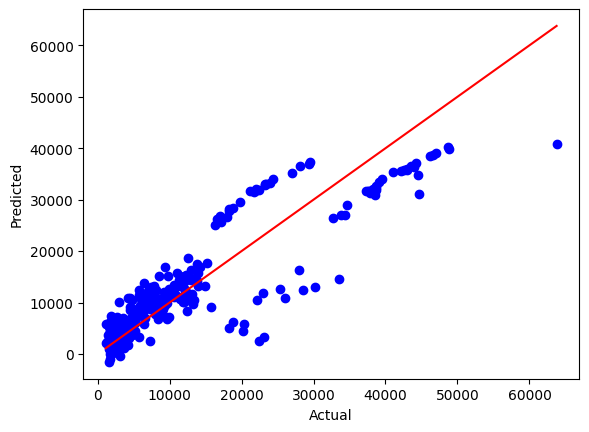

In [23]:
plt.scatter(y_test,Prediction,color='Blue')
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],color='Red')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

In [30]:
data_churn = pd.read_csv('/content/Telco Customer Churn.csv')
df_churn = pd.DataFrame(data_churn)
df_churn

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [31]:
df_churn = pd.get_dummies(df_churn,columns=['Contract'],dtype=int)
df_churn = pd.get_dummies(df_churn,columns=['InternetService'],dtype=int)

df_churn

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,...,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Contract_Month-to-month,Contract_One year,Contract_Two year,InternetService_DSL,InternetService_Fiber optic,InternetService_No
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,No,Yes,...,Electronic check,29.85,29.85,No,1,0,0,1,0,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,Yes,No,...,Mailed check,56.95,1889.5,No,0,1,0,1,0,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,Yes,Yes,...,Mailed check,53.85,108.15,Yes,1,0,0,1,0,0
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,Yes,No,...,Bank transfer (automatic),42.30,1840.75,No,0,1,0,1,0,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,No,No,...,Electronic check,70.70,151.65,Yes,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,Yes,No,...,Mailed check,84.80,1990.5,No,0,1,0,1,0,0
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,No,Yes,...,Credit card (automatic),103.20,7362.9,No,0,1,0,0,1,0
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,Yes,No,...,Electronic check,29.60,346.45,No,1,0,0,1,0,0
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,No,No,...,Mailed check,74.40,306.6,Yes,1,0,0,0,1,0


In [32]:
df_churn['Churn'] = df_churn['Churn'].map({'No':0,'Yes':1})

In [33]:
df_churn

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,...,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Contract_Month-to-month,Contract_One year,Contract_Two year,InternetService_DSL,InternetService_Fiber optic,InternetService_No
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,No,Yes,...,Electronic check,29.85,29.85,0,1,0,0,1,0,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,Yes,No,...,Mailed check,56.95,1889.5,0,0,1,0,1,0,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,Yes,Yes,...,Mailed check,53.85,108.15,1,1,0,0,1,0,0
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,Yes,No,...,Bank transfer (automatic),42.30,1840.75,0,0,1,0,1,0,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,No,No,...,Electronic check,70.70,151.65,1,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,Yes,No,...,Mailed check,84.80,1990.5,0,0,1,0,1,0,0
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,No,Yes,...,Credit card (automatic),103.20,7362.9,0,0,1,0,0,1,0
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,Yes,No,...,Electronic check,29.60,346.45,0,1,0,0,1,0,0
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,No,No,...,Mailed check,74.40,306.6,1,1,0,0,0,1,0


In [34]:
# Tenure,MonthlyCharges,Contract,Iternetservices
df_churn[['tenure','MonthlyCharges']]  = scaler.fit_transform(df_churn[['tenure','MonthlyCharges']])

In [35]:
df_churn


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,...,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Contract_Month-to-month,Contract_One year,Contract_Two year,InternetService_DSL,InternetService_Fiber optic,InternetService_No
0,7590-VHVEG,Female,0,Yes,No,-1.277445,No,No phone service,No,Yes,...,Electronic check,-1.160323,29.85,0,1,0,0,1,0,0
1,5575-GNVDE,Male,0,No,No,0.066327,Yes,No,Yes,No,...,Mailed check,-0.259629,1889.5,0,0,1,0,1,0,0
2,3668-QPYBK,Male,0,No,No,-1.236724,Yes,No,Yes,Yes,...,Mailed check,-0.362660,108.15,1,1,0,0,1,0,0
3,7795-CFOCW,Male,0,No,No,0.514251,No,No phone service,Yes,No,...,Bank transfer (automatic),-0.746535,1840.75,0,0,1,0,1,0,0
4,9237-HQITU,Female,0,No,No,-1.236724,Yes,No,No,No,...,Electronic check,0.197365,151.65,1,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,-0.340876,Yes,Yes,Yes,No,...,Mailed check,0.665992,1990.5,0,0,1,0,1,0,0
7039,2234-XADUH,Female,0,Yes,Yes,1.613701,Yes,Yes,No,Yes,...,Credit card (automatic),1.277533,7362.9,0,0,1,0,0,1,0
7040,4801-JZAZL,Female,0,Yes,Yes,-0.870241,No,No phone service,Yes,No,...,Electronic check,-1.168632,346.45,0,1,0,0,1,0,0
7041,8361-LTMKD,Male,1,Yes,No,-1.155283,Yes,Yes,No,No,...,Mailed check,0.320338,306.6,1,1,0,0,0,1,0


In [36]:
df_churn.columns


Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn', 'Contract_Month-to-month',
       'Contract_One year', 'Contract_Two year', 'InternetService_DSL',
       'InternetService_Fiber optic', 'InternetService_No'],
      dtype='object')

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
LRR = LogisticRegression()
X_Churn = df_churn[['tenure','InternetService_DSL','InternetService_Fiber optic','InternetService_No','MonthlyCharges','Contract_Month-to-month','Contract_One year', 'Contract_Two year']]
Y_churn = df_churn['Churn']


xc_train,xc_test,yc_train,yc_test = train_test_split(X_Churn,Y_churn,test_size=0.2,random_state=42)
LRR.fit(xc_train,yc_train)
predict = LRR.predict(xc_test)
acc = accuracy_score(yc_test,predict)
prec = precision_score(yc_test,predict)
recal = recall_score(yc_test,predict)
f1 = f1_score(yc_test,predict)

print('Accuracy',acc)
print('Precision',prec)
print('Recall',recal)
print('f1',f1)

Accuracy 0.8026969481902059
Precision 0.6588628762541806
Recall 0.5281501340482574
f1 0.5863095238095238


In [38]:
# ACTIVITY 3

In [40]:
data_car = pd.read_csv('/content/Car Price Prediction.csv')
df_car = pd.DataFrame(data_car)
df_car


,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,201,-1,volvo 145e (sw),gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845.0
201,202,-1,volvo 144ea,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045.0
202,203,-1,volvo 244dl,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485.0
203,204,-1,volvo 246,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.40,23.0,106,4800,26,27,22470.0


In [41]:
df_car = pd.get_dummies(df_car,columns=['fueltype'],dtype=int)

In [42]:
df_car.columns

Index(['car_ID', 'symboling', 'CarName', 'aspiration', 'doornumber', 'carbody',
       'drivewheel', 'enginelocation', 'wheelbase', 'carlength', 'carwidth',
       'carheight', 'curbweight', 'enginetype', 'cylindernumber', 'enginesize',
       'fuelsystem', 'boreratio', 'stroke', 'compressionratio', 'horsepower',
       'peakrpm', 'citympg', 'highwaympg', 'price', 'fueltype_diesel',
       'fueltype_gas'],
      dtype='object')

In [43]:
X_Car = df_car[['enginesize','stroke','horsepower','fueltype_diesel','fueltype_gas']]
Y_Car = df_car['price']

In [44]:
X_Car

,enginesize,stroke,horsepower,fueltype_diesel,fueltype_gas
0,130,2.68,111,0,1
1,130,2.68,111,0,1
2,152,3.47,154,0,1
3,109,3.40,102,0,1
4,136,3.40,115,0,1
...,...,...,...,...,...
200,141,3.15,114,0,1
201,141,3.15,160,0,1
202,173,2.87,134,0,1
203,145,3.40,106,1,0


In [45]:
from sklearn.preprocessing import StandardScaler
Scaler1 = StandardScaler()
df_car[['enginesize','stroke','horsepower','fueltype_gas','fueltype_diesel']] = Scaler1.fit_transform(df_car[['enginesize','stroke','horsepower','fueltype_gas','fueltype_diesel']])



In [46]:
X_Car

,enginesize,stroke,horsepower,fueltype_diesel,fueltype_gas
0,130,2.68,111,0,1
1,130,2.68,111,0,1
2,152,3.47,154,0,1
3,109,3.40,102,0,1
4,136,3.40,115,0,1
...,...,...,...,...,...
200,141,3.15,114,0,1
201,141,3.15,160,0,1
202,173,2.87,134,0,1
203,145,3.40,106,1,0


In [47]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
LRR2 = LinearRegression()
x_train,x_test,y_train,y_test = train_test_split(X_Car,Y_Car,test_size=0.2,random_state=42)
LRR2.fit(x_train,y_train)
y_predict = LRR2.predict(x_test)
R2_score = r2_score(y_test,y_predict)
print('R2 Score is: ',R2_score)



R2 Score is:  0.8371196464798624
